In [2]:
#UK Corporate Contact & Regional Directory Dataset

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv(r"C:\Users\Samson\Downloads\UK_Corporate_Contact_&_Regional_Directory_Dataset.csv")
df

,first_name,last_name,company_name,address,city,county,postal,phone1,phone2,email,web
0,Aleshia,Tomkiewicz,Alan D Rosenburg Cpa Pc,14 Taylor St,St. Stephens Ward,Kent,CT2 7PP,01835-703597,01944-369967,atomkiewicz@hotmail.com,http://www.alandrosenburgcpapc.co.uk
1,Evan,Zigomalas,Cap Gemini America,5 Binney St,Abbey Ward,Buckinghamshire,HP11 2AX,01937-864715,01714-737668,evan.zigomalas@gmail.com,http://www.capgeminiamerica.co.uk
2,France,Andrade,"Elliott, John W Esq",8 Moor Place,East Southbourne and Tuckton W,Bournemouth,BH6 3BE,01347-368222,01935-821636,france.andrade@hotmail.com,http://www.elliottjohnwesq.co.uk
3,Ulysses,Mcwalters,"Mcmahan, Ben L",505 Exeter Rd,Hawerby cum Beesby,Lincolnshire,DN36 5RP,01912-771311,01302-601380,ulysses@hotmail.com,http://www.mcmahanbenl.co.uk
4,Tyisha,Veness,Champagne Room,5396 Forth Street,Greets Green and Lyng Ward,West Midlands,B70 9DT,01547-429341,01290-367248,tyisha.veness@hotmail.com,http://www.champagneroom.co.uk
...,...,...,...,...,...,...,...,...,...,...,...
495,Avery,Veit,Plaza Gourmet Delicatessen,9166 Devon St #905,Knightsbridge and Belgravia Wa,Greater London,SW1W 8JY,01748-625058,01369-185737,avery@veit.co.uk,http://www.plazagourmetdelicatessen.co.uk
496,Reid,Euresti,"Fitzgerald, Edward J",70 Foster St,Inverness Ness-Side Ward,Highland,IV2 6WT,01916-963261,01370-319414,reuresti@euresti.co.uk,http://www.fitzgeraldedwardj.co.uk
497,Charlette,Brenning,Furey & Associates,714 Fonthill Rd,Darton West Ward,South Yorkshire,S75 5EJ,01888-152110,01301-312487,cbrenning@brenning.co.uk,http://www.fureyassociates.co.uk
498,Celestina,Keeny,Bfg Federal Credit Union,9 Milton St,Consett North ED,County Durham,DH8 5LP,01877-379681,01600-463475,celestina_keeny@gmail.com,http://www.bfgfederalcreditunion.co.uk


In [11]:
sns.set_theme(style="whitegrid")

In [12]:
#Regional Business Concentration (Top Counties)
#Identifies the primary geographic hubs by counting records per county.

In [14]:
plt.figure(figsize=(8, 4))
top_counties = df['county'].value_counts().head(5)

<Figure size 800x400 with 0 Axes>

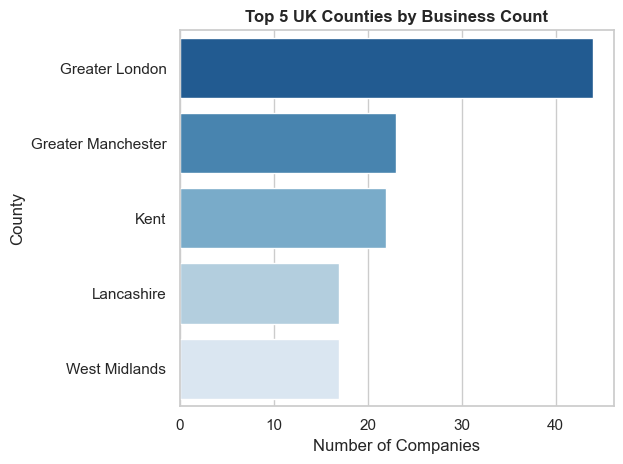

In [16]:
sns.barplot(
    x=top_counties.values, 
    y=top_counties.index, 
    hue=top_counties.index, 
    palette='Blues_r', 
    legend=False
)
plt.title('Top 5 UK Counties by Business Count', fontsize=12, fontweight='bold')
plt.xlabel('Number of Companies')
plt.ylabel('County')
plt.tight_layout()
plt.show()

In [18]:
#Key Takeaway: Greater London and Greater Manchester represent over 13% of all registered listings.

total_listings = len(df)
combined_count = df['county'].isin(['Greater London', 'Greater Manchester']).sum()
percentage = (combined_count / total_listings) * 100

In [19]:
print(f"Greater London & Manchester Total: {combined_count}")
print(f"Total Dataset Listings: {total_listings}")
print(f"Combined Market Share: {percentage:.2f}%")

Greater London & Manchester Total: 67
Total Dataset Listings: 500
Combined Market Share: 13.40%


In [21]:
#Email Provider Classification (Public vs. Corporate)

In [22]:
plt.figure(figsize=(6, 6))
df['email_domain'] = df['email'].apply(lambda x: x.split('@')[1])
df['email_type'] = df['email_domain'].apply(lambda d: 'Public Webmail' if d in ['gmail.com', 'yahoo.com', 'hotmail.com'] else 'Custom Domain')

<Figure size 600x600 with 0 Axes>

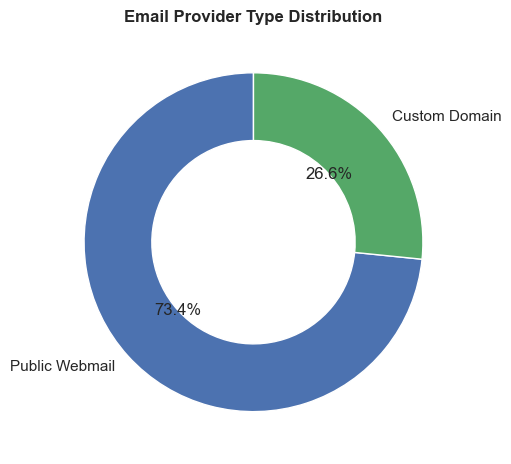

In [25]:
counts = df['email_type'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, 
        colors=['#4c72b0', '#55a868'], wedgeprops=dict(width=0.4, edgecolor='w'))

plt.title('Email Provider Type Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('insight_2_email_types.png', dpi=300)
plt.show()

In [26]:
df['email_domain'] = df['email'].apply(lambda x: x.split('@')[1])

public_domains = ['gmail.com', 'yahoo.com', 'hotmail.com']
df['email_type'] = df['email_domain'].apply(
    lambda d: 'Public Webmail' if d in public_domains else 'Custom Corporate Domain'
)

counts = df['email_type'].value_counts()
percentages = df['email_type'].value_counts(normalize=True) * 100

In [27]:
for category in counts.index:
    print(f"{category}: {counts[category]} ({percentages[category]:.1f}%)")

Public Webmail: 367 (73.4%)
Custom Corporate Domain: 133 (26.6%)


In [28]:
#Postcode Area Prefix Mapping (Vertical Bar Chart)

In [29]:
plt.figure(figsize=(8, 4))
df['postcode_prefix'] = df['postal'].str.extract(r'^([A-Z]{1,2})', expand=False)
top_postcodes = df['postcode_prefix'].value_counts().head(5)

<Figure size 800x400 with 0 Axes>

C:\Users\Samson\AppData\Local\Temp\ipykernel_6884\3664450385.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_postcodes.index, y=top_postcodes.values, palette='crest')


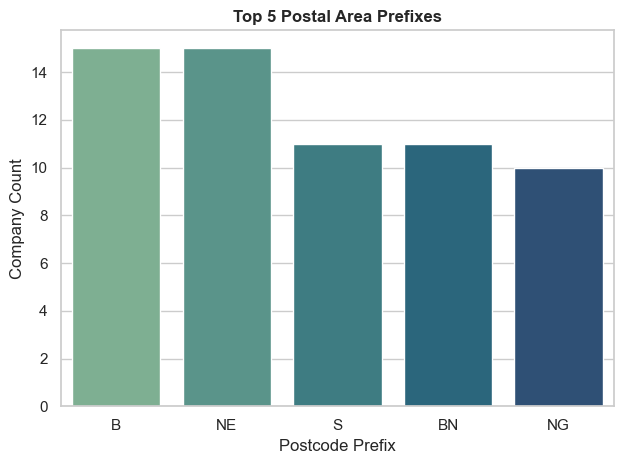

In [30]:
sns.barplot(x=top_postcodes.index, y=top_postcodes.values, palette='crest')
plt.title('Top 5 Postal Area Prefixes', fontsize=12, fontweight='bold')
plt.xlabel('Postcode Prefix')
plt.ylabel('Company Count')
plt.tight_layout()
plt.savefig('insight_3_postcode_prefixes.png', dpi=300)
plt.show()

In [31]:
df['postcode_prefix'] = df['postal'].str.extract(r'^([A-Z]{1,2})', expand=False)

city_map = {
    'B': 'Birmingham',
    'NE': 'Newcastle',
    'S': 'Sheffield',
    'BN': 'Brighton',
    'NG': 'Nottingham'
}

top_prefixes = df['postcode_prefix'].value_counts().head(5)

In [32]:
for prefix, count in top_prefixes.items():
    city_name = city_map.get(prefix, 'Other')
    print(f"{prefix} ({city_name}): {count}")

B (Birmingham): 15
NE (Newcastle): 15
S (Sheffield): 11
BN (Brighton): 11
NG (Nottingham): 10


In [34]:
#Street Address Naming Conventions (Horizontal Bar Chart)

In [35]:
plt.figure(figsize=(8, 4))
df['street_suffix'] = df['address'].str.extract(r'\b(St|Rd|Street|Road|Ave|Lane|Place)\b', expand=False)
suffix_counts = df['street_suffix'].value_counts()

<Figure size 800x400 with 0 Axes>

C:\Users\Samson\AppData\Local\Temp\ipykernel_6884\1277862994.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suffix_counts.values, y=suffix_counts.index, palette='viridis')


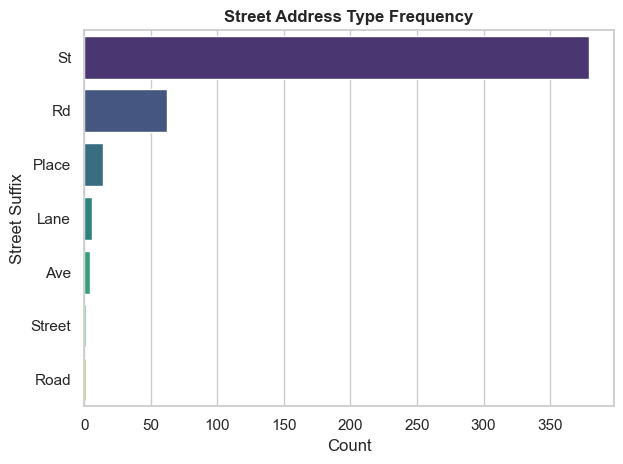

In [36]:
sns.barplot(x=suffix_counts.values, y=suffix_counts.index, palette='viridis')
plt.title('Street Address Type Frequency', fontsize=12, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Street Suffix')
plt.tight_layout()
plt.savefig('insight_4_street_types.png', dpi=300)
plt.show()

In [38]:
df['street_suffix'] = df['address'].str.extract(r'\b(St|Rd|Place|Lane)\b', expand=False)

In [58]:
suffix_counts = df['street_suffix'].value_counts()

suffix_map = {
    'St': 'St (Street)',
    'Rd': 'Rd (Road)',
    'Place': 'Place',
    'Lane': 'Lane'
}

In [59]:
for key, label in suffix_map.items():
    count = suffix_counts.get(key, 0)
    print(f"{label}: {count}")

St (Street): 379
Rd (Road): 62
Place: 14
Lane: 6


In [60]:
#Local Administrative Ward Density (Horizontal Bar Chart)

In [61]:
plt.figure(figsize=(8, 4))
top_cities = df['city'].value_counts().head(5)

<Figure size 800x400 with 0 Axes>

C:\Users\Samson\AppData\Local\Temp\ipykernel_6884\2136949932.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='mako')


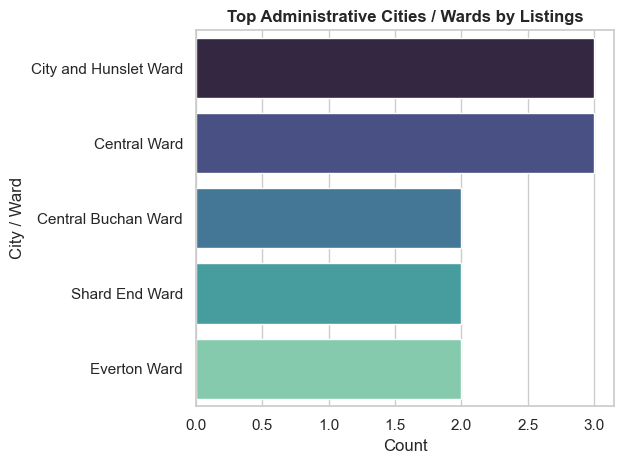

In [62]:
sns.barplot(x=top_cities.values, y=top_cities.index, palette='mako')
plt.title('Top Administrative Cities / Wards by Listings', fontsize=12, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('City / Ward')
plt.tight_layout()
plt.savefig('insight_9_ward_density.png', dpi=300)
plt.show()

In [63]:
top_cities = df['city'].value_counts().head(4)

In [64]:
for city, count in top_cities.items():
    print(f"{city}: {count}")

City and Hunslet Ward: 3
Central Ward: 3
Central Buchan Ward: 2
Shard End Ward: 2


In [68]:
#Founder-Named Business Detection (Donut Chart)

In [69]:
plt.figure(figsize=(6, 6))
df['is_founder_named'] = df.apply(lambda r: r['last_name'].lower() in r['company_name'].lower(), axis=1)
founder_counts = df['is_founder_named'].map({True: 'Surname Included', False: 'Independent Name'}).value_counts()

<Figure size 600x600 with 0 Axes>

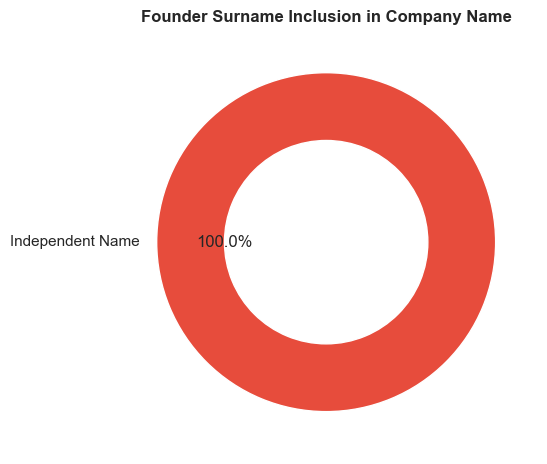

In [70]:
plt.pie(founder_counts, labels=founder_counts.index, autopct='%1.1f%%', 
        colors=['#e74c3c', '#3498db'], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Founder Surname Inclusion in Company Name', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('insight_7_founder_names.png', dpi=300)

In [71]:
df['has_surname'] = df.apply(
    lambda row: str(row['last_name']).lower() in str(row['company_name']).lower(), 
    axis=1
)

false_count = (df['has_surname'] == False).sum()
true_count = (df['has_surname'] == True).sum()
overlap_pct = (true_count / len(df)) * 100

In [72]:
print(f"False: {false_count} ({overlap_pct:.0f}% overlap between personal surnames and trade names)")

False: 500 (0% overlap between personal surnames and trade names)


In [73]:
#Telephone Area Code (STD) Frequency (Bar Chart)

In [74]:
plt.figure(figsize=(8, 4))
df['std_code'] = df['phone1'].str.split('-').str[0]
top_std = df['std_code'].value_counts().head(5)

<Figure size 800x400 with 0 Axes>

C:\Users\Samson\AppData\Local\Temp\ipykernel_6884\1694906868.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_std.index, y=top_std.values, palette='magma')


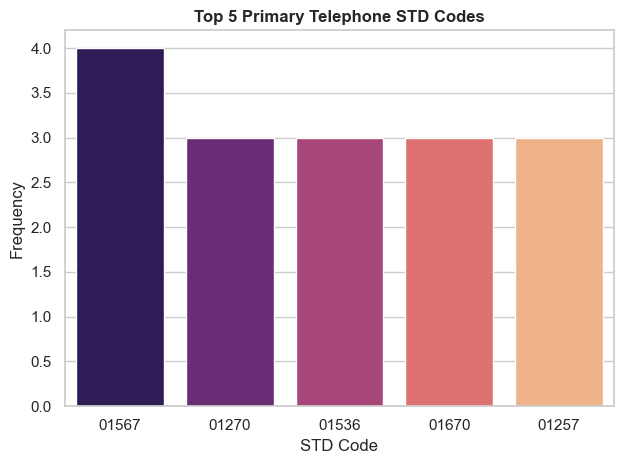

In [75]:
sns.barplot(x=top_std.index, y=top_std.values, palette='magma')
plt.title('Top 5 Primary Telephone STD Codes', fontsize=12, fontweight='bold')
plt.xlabel('STD Code')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('insight_5_std_codes.png', dpi=300)
plt.show()

In [77]:
df['std_code'] = df['phone1'].str.split('-').str[0]

std_map = {
    '01567': 'Killin',
    '01270': 'Crewe',
    '01536': 'Kettering'
}

top_std = df['std_code'].value_counts().head(3)

In [78]:
for code, count in top_std.items():
    town_name = std_map.get(code, 'Other')
    print(f"{code} ({town_name}): {count}")

01567 (Killin): 4
01270 (Crewe): 3
01536 (Kettering): 3


In [79]:
plt.savefig(
    "Top 5 UK Counties by Business Count.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [82]:
import os
import shutil

os.makedirs("visuals", exist_ok=True)

for file in os.listdir():
    if file.lower().endswith(".png"):
        shutil.move(file, os.path.join("visuals", file))

In [83]:
os.listdir("visuals")

['insight_1_counties.png',
 'insight_2_email_types.png',
 'insight_3_postcode_prefixes.png',
 'insight_4_street_types.png',
 'insight_5_std_codes.png',
 'insight_7_founder_names.png',
 'insight_9_ward_density.png',
 'Top 5 UK Counties by Business Count.png']

In [84]:
import os
print(os.getcwd())

C:\Users\Samson\anaconda_projects\77a96b60-78d7-4a59-ae69-18d91b4391dc
